# 02_03. Matched short-read vs PacBio gene-level correlation (shared barcodes)

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, spearmanr
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CSVS_DIR = "./../csvs"
FIG_DIR  = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.0
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.labelspacing": 0.1, "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2, "legend.title_fontsize": 6,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD, "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

## 1. Config + streaming-pseudobulk helpers

The helpers read a CSR `.h5ad` matrix in row-blocks and accumulate per-group summed counts
(`group_indicator @ block`), so peak memory stays small even for the SR object.

In [3]:
PACBIO_GENES = f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_preprocessed.h5ad"
SHORTREAD    = f"{H5AD_DIR}/all_donors_shortread_LR_matched_anndata.h5ad"

# Donor display order (PacBio core donors; SR sample_id prefixes map onto these)
DONOR_ORDER = ["TSP2", "TSP4", "TSP7", "TSP9", "TSP10", "TSP19",
               "TSP21", "TSP25", "TSP27", "TSP28", "TSP32", "TSP33"]

MIN_CELLS_PER_GROUP = 20   # skip donor/sample pseudobulks with fewer cells than this


def _decode(v):
    return np.array([x.decode() if isinstance(x, bytes) else x for x in v])


def read_obs_col(path, name):
    """Read one obs column (handles categorical + string/numeric); codes==-1 -> None."""
    with h5py.File(path, "r") as f:
        o = f["obs"][name]
        if isinstance(o, h5py.Group):                      # categorical
            cats = _decode(o["categories"][:])
            codes = o["codes"][:]
            out = np.full(codes.shape[0], None, dtype=object)
            valid = codes >= 0
            out[valid] = cats[codes[valid]]
            return out
        v = o[:]
        return _decode(v) if v.dtype.kind in ("S", "O") else v


def read_var_symbols(path, col):
    """Read a var column of gene symbols aligned to the var index."""
    with h5py.File(path, "r") as f:
        o = f["var"][col]
        if isinstance(o, h5py.Group):
            cats = _decode(o["categories"][:])
            return cats[o["codes"][:]]
        return _decode(o[:])


def pseudobulk_stream(path, matrix_key, group_labels, groups_order, block=40000):
    """Stream a CSR matrix and return (n_groups x n_var) summed counts + per-group n_cells.

    group_labels: per-cell array of group names. Cells whose label is not in
    groups_order are skipped.
    """
    g2i = {g: i for i, g in enumerate(groups_order)}
    codes = np.array([g2i.get(x, -1) for x in group_labels], dtype=np.int64)
    ng = len(groups_order)
    with h5py.File(path, "r") as f:
        M = f[matrix_key]
        n_var = int(M.attrs["shape"][1])
        indptr = M["indptr"][:]
        data, indices = M["data"], M["indices"]
        n_cells = indptr.shape[0] - 1
        acc = np.zeros((ng, n_var), dtype=np.float64)
        ncell = np.zeros(ng, dtype=np.int64)
        for r0 in range(0, n_cells, block):
            r1 = min(r0 + block, n_cells)
            cblk = codes[r0:r1]
            mask = cblk >= 0
            if not mask.any():
                continue
            s, e = int(indptr[r0]), int(indptr[r1])
            Xblk = csr_matrix((data[s:e], indices[s:e], indptr[r0:r1 + 1] - s),
                              shape=(r1 - r0, n_var))
            rows = np.nonzero(mask)[0]
            Gblk = csr_matrix((np.ones(rows.size), (cblk[mask], rows)),
                              shape=(ng, r1 - r0))
            acc += (Gblk @ Xblk).toarray()
            np.add.at(ncell, cblk[mask], 1)
    return acc, ncell


def pool_by_symbol(sums, symbols, groups):
    """Collapse duplicated gene symbols (scanpy make-unique suffixes) by summing -> genes x groups."""
    dfT = pd.DataFrame(sums.T, index=pd.Index(symbols, name="gene"))
    pooled = dfT.groupby(level=0).sum()
    pooled.columns = list(groups)
    return pooled


def cp10k_log1p(pooled):
    """Column-wise counts-per-10k + log1p (each group normalized to 1e4 total)."""
    col_sums = pooled.sum(axis=0).replace(0, np.nan)
    return np.log1p(pooled.div(col_sums, axis=1) * 1e4)

    
def corr_pair(a, b, min_genes=50):
    """Pearson/Spearman between two aligned log1p-CP10K gene vectors over union-detected genes."""
    m = (a.values > 0) | (b.values > 0)
    if m.sum() < min_genes:
        return np.nan, np.nan, int(m.sum())
    x, y = a.values[m], b.values[m]
    return pearsonr(x, y)[0], spearmanr(x, y)[0], int(m.sum())


def reverse_complement(seq):
    """Reverse complement a DNA sequence (02_04 recipe)."""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G', 'N': 'N'}
    return ''.join(comp.get(b, b) for b in seq[::-1])


def read_index(path):
    """Read obs_names (the barcode index) from an .h5ad."""
    with h5py.File(path, "r") as f:
        return _decode(f["obs"]["_index"][:])


print("Helpers defined.")

Helpers defined.


## 2. PacBio grouping labels

Read the PacBio grouping labels (`donor`, `SR_sample_id`) and gene symbols (`gene_name`) — small
metadata reads, no matrix load. The pseudobulk itself is built later over shared barcodes only.

In [4]:
# Grouping labels + gene symbols (small metadata reads, no matrix load)
pb_donor_labels  = read_obs_col(PACBIO_GENES, "donor")
pb_sample_labels = read_obs_col(PACBIO_GENES, "SR_sample_id")
pb_symbols       = read_var_symbols(PACBIO_GENES, "gene_name")

PB_DONORS = [d for d in DONOR_ORDER if d in set(pb_donor_labels)]
print("PacBio donors:", PB_DONORS)

# matched samples (drop "No match found")
pb_samples = [s for s in np.unique(pb_sample_labels[pb_sample_labels != None])
              if s not in ("No match found",)]
print("PacBio matched samples:", len(pb_samples))

PacBio donors: ['TSP2', 'TSP4', 'TSP7', 'TSP9', 'TSP10', 'TSP19', 'TSP21', 'TSP25', 'TSP27', 'TSP28', 'TSP32', 'TSP33']
PacBio matched samples: 57


## 3. Short-read grouping labels

Read the SR grouping labels. The SR donor is the `sample_id` prefix (`TSP*`), and `sample_id`
matches PacBio `SR_sample_id` directly. Gene symbols come from `gene_symbol`.

In [5]:
sr_sample_labels = read_obs_col(SHORTREAD, "sample_id")
sr_donor_labels  = np.array([str(s).split("_")[0] if s is not None else None
                             for s in sr_sample_labels], dtype=object)
sr_symbols       = read_var_symbols(SHORTREAD, "gene_symbol")

SR_DONORS = [d for d in DONOR_ORDER if d in set(sr_donor_labels)]
print("SR donors (from sample_id prefix):", SR_DONORS)

SR donors (from sample_id prefix): ['TSP2', 'TSP4', 'TSP7', 'TSP9', 'TSP10', 'TSP19', 'TSP21', 'TSP25', 'TSP27', 'TSP28', 'TSP32', 'TSP33']


## 4. Matched donors

Donors present in both platforms. Gene alignment (shared symbols) happens inside the
shared-barcode pseudobulk below.

In [6]:
MATCHED_DONORS = [d for d in DONOR_ORDER if d in PB_DONORS and d in SR_DONORS]
print("Matched donors:", MATCHED_DONORS)

Matched donors: ['TSP2', 'TSP4', 'TSP7', 'TSP9', 'TSP10', 'TSP19', 'TSP21', 'TSP25', 'TSP27', 'TSP28', 'TSP32', 'TSP33']


### Reusable correlation + plotting functions

Per-donor scatter and per-sample correlation, called on the shared-barcode pseudobulks below.

In [7]:
def perdonor_scatter(pb_l, sr_l, matched_donors, pb_ncell_map, sr_ncell_map, title, savepath, pctl=100):
    ncol = 4
    nrow = int(np.ceil(len(matched_donors) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(1.30 * ncol, 1.40 * nrow))
    axes = np.atleast_1d(axes).ravel()
    rows = []
    for k, d in enumerate(matched_donors):
        ax = axes[k]
        a, b = pb_l[d], sr_l[d]
        m = (a.values > 0) | (b.values > 0)
        pr, sp, ng = corr_pair(a, b)
        rows.append({"donor": d, "pearson": pr, "spearman": sp, "n_genes": ng,
                     "pb_cells": int(pb_ncell_map.get(d, 0)), "sr_cells": int(sr_ncell_map.get(d, 0))})
        ax.scatter(a.values[m], b.values[m], s=0.5, alpha=0.15, edgecolors="none",
                   color="#3182bd", rasterized=True)
        # axis limit = high percentile (pctl) of the plotted values per panel, so a few
        # outlier genes don't stretch the axes and cluster everything near the origin.
        vals = np.concatenate([a.values[m], b.values[m]])
        lim = float(np.percentile(vals, pctl)) if vals.size else 1.0
        ax.plot([0, lim], [0, lim], color="grey", lw=0.5, ls="--")
        ax.set_xlim(0, lim)                 # identical x/y range so the diagonal is 1:1
        ax.set_ylim(0, lim)
        ax.set_aspect("equal")
        ax.set_title(f"{d}\nr={pr:.2f}  ρ={sp:.2f}", pad=PANEL_TITLE_PAD)
        ax.set_xlabel("PacBio log1p CP10K")
        ax.set_ylabel("SR log1p CP10K")
    for j in range(len(matched_donors), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, y = 0.97)
    # plt.tight_layout()
    plt.subplots_adjust(wspace = 0.4, hspace = 0.70)
    plt.savefig(savepath, dpi=600)
    plt.show()
    return pd.DataFrame(rows).set_index("donor")


def persample_corr(pb_sample_counts, sr_sample_counts, pb_sample_ncell, sr_sample_ncell,
                   samples, min_cells, title, savepath):
    samp_shared = sorted(set(pb_sample_counts.index) & set(sr_sample_counts.index))
    pb_sl = cp10k_log1p(pb_sample_counts).loc[samp_shared]
    sr_sl = cp10k_log1p(sr_sample_counts).loc[samp_shared]
    rows = []
    for s in samples:
        npb, nsr = int(pb_sample_ncell.get(s, 0)), int(sr_sample_ncell.get(s, 0))
        if npb < min_cells or nsr < min_cells:
            continue
        pr, sp, ng = corr_pair(pb_sl[s], sr_sl[s])
        rows.append({"sample": s, "donor": s.split("_")[0], "tissue": s.split("_")[1],
                     "pearson": pr, "spearman": sp, "n_genes": ng, "pb_cells": npb, "sr_cells": nsr})
    psc = pd.DataFrame(rows)
    if len(psc):
        psc = psc.sort_values("donor")
        donors_present = [d for d in DONOR_ORDER if d in set(psc["donor"])]
        from TS_colorDict import donor_colors
        dcol = donor_colors()
        palette = {d: dcol.get(d, "#666666") for d in donors_present}
        fig, axes = plt.subplots(2, 1, figsize=(1.5, 3.5))
        # one box per donor over its per-sample correlations, with individual sample points overlaid
        sns.boxplot(data=psc, x="donor", y="pearson", order=donors_present,
                    hue="donor", hue_order=donors_present, palette=palette, legend=False,
                    showfliers=False, width=0.6, linewidth=0.6, ax=axes[0])
        sns.stripplot(data=psc, x="donor", y="pearson", order=donors_present,
                      color="black", size=2, alpha=0.7, jitter=0.25, ax=axes[0])
        axes[0].set_xlabel("Donor")
        axes[0].set_ylabel("Pearson r (SR vs LR)")
        axes[0].set_ylim(0, 1)
        axes[0].tick_params(axis="x", rotation=60)
        axes[0].set_title(title, pad=PANEL_TITLE_PAD)
        mincells = psc[["pb_cells", "sr_cells"]].min(axis=1)
        axes[1].scatter(mincells, psc["pearson"], s=8, c=[palette[d] for d in psc["donor"]])
        axes[1].set_xscale("log")
        axes[1].set_xlabel("min(PacBio, SR) cells per sample")
        axes[1].set_ylabel("Pearson r")
        axes[1].set_ylim(0, 1)
        axes[1].set_title("Correlation vs cell depth", pad=PANEL_TITLE_PAD)
        # plt.tight_layout()
        plt.subplots_adjust(hspace= 0.6)
        plt.savefig(savepath, dpi=300)
        plt.show()
    return psc

print("Plotting helpers defined.")

Plotting helpers defined.


## 5. Shared-barcode (same-cell) analysis

Correlate on **shared barcodes only** — cells captured by *both* platforms.
Match key (from `02_04`): PacBio `SR_sample_id + "___" + reverse_complement(barcode)` vs
short-read `sample_id + "___" + 10X_barcode` (PacBio barcodes are stored reverse-complemented).
Each platform is then pseudobulked over **only** the intersecting cells, so composition is
identical on both sides. Below: per-donor scatter and per-sample (tissue-controlled) correlation.

In [8]:
# --- build per-cell match keys (02_04 recipe) ---
pb_obs_names = read_index(PACBIO_GENES)
pb_bc_rc = np.array([reverse_complement(x.split("-1")[0]) for x in pb_obs_names], dtype=object)
pb_key = np.array([f"{s}___{b}" if s not in (None, "No match found") else None
                   for s, b in zip(pb_sample_labels, pb_bc_rc)], dtype=object)
sr_key = read_obs_col(SHORTREAD, "sample_id_10X_barcode")

shared_keys = set(k for k in pb_key if k is not None) & set(k for k in sr_key if k is not None)
pb_in = np.array([k in shared_keys for k in pb_key])
sr_in = np.array([k in shared_keys for k in sr_key])
print(f"Shared barcode-cells: {len(shared_keys)}")
print(f"PacBio cells kept: {pb_in.sum()} / {len(pb_key)}  |  SR cells kept: {sr_in.sum()} / {len(sr_key)}")

# --- restrict grouping labels to shared cells (others -> None so pseudobulk skips them) ---
pb_donor_sh  = np.where(pb_in, pb_donor_labels, None)
sr_donor_sh  = np.where(sr_in, sr_donor_labels, None)
pb_sample_sh = np.where(pb_in, pb_sample_labels, None)
sr_sample_sh = np.where(sr_in, sr_sample_labels, None)

# --- donor-level pseudobulk over shared cells ---
pb_sums_sh, pb_ncell_sh = pseudobulk_stream(PACBIO_GENES, "X", pb_donor_sh, PB_DONORS)
pb_donor_log_sh = cp10k_log1p(pool_by_symbol(pb_sums_sh, pb_symbols, PB_DONORS))
sr_sums_sh, sr_ncell_sh = pseudobulk_stream(SHORTREAD, "layers/raw_counts", sr_donor_sh, SR_DONORS)
sr_donor_log_sh = cp10k_log1p(pool_by_symbol(sr_sums_sh, sr_symbols, SR_DONORS))

# sanity: per-donor shared cell counts should match between platforms (same physical cells)
_chk = pd.DataFrame({"pb": pd.Series(pb_ncell_sh, index=PB_DONORS),
                     "sr": pd.Series(sr_ncell_sh, index=SR_DONORS)})
print("shared cells per donor (pb == sr expected):")
print(_chk)

# --- sample-level pseudobulk over shared cells ---
pb_ssums_sh, pb_sncell_sh = pseudobulk_stream(PACBIO_GENES, "X", pb_sample_sh, pb_samples)
pb_sample_counts_sh = pool_by_symbol(pb_ssums_sh, pb_symbols, pb_samples)
pb_sample_ncell_sh = pd.Series(pb_sncell_sh, index=pb_samples)
sr_ssums_sh, sr_sncell_sh = pseudobulk_stream(SHORTREAD, "layers/raw_counts", sr_sample_sh, pb_samples)
sr_sample_counts_sh = pool_by_symbol(sr_ssums_sh, sr_symbols, pb_samples)
sr_sample_ncell_sh = pd.Series(sr_sncell_sh, index=pb_samples)

# --- align shared-barcode donor pseudobulk ---
shared_genes_sh = sorted(set(pb_donor_log_sh.index) & set(sr_donor_log_sh.index))
pb_l_sh = pb_donor_log_sh.loc[shared_genes_sh, MATCHED_DONORS]
sr_l_sh = sr_donor_log_sh.loc[shared_genes_sh, MATCHED_DONORS]
print("shared-barcode aligned:", pb_l_sh.shape)
gc.collect()

Shared barcode-cells: 160891
PacBio cells kept: 160891 / 203311  |  SR cells kept: 160891 / 634764
shared cells per donor (pb == sr expected):
          pb     sr
TSP2    6457   6457
TSP4    3057   3057
TSP7    6353   6353
TSP9    3089   3089
TSP10   2713   2713
TSP19   2163   2163
TSP21  19222  19222
TSP25  17690  17690
TSP27  45423  45423
TSP28   9640   9640
TSP32   1716   1716
TSP33  43368  43368
shared-barcode aligned: (41360, 12)


20

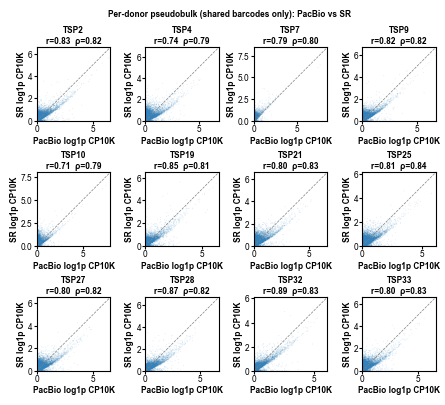

       pearson  spearman  n_genes  pb_cells  sr_cells
donor                                                
TSP2     0.829     0.824    36142      6457      6457
TSP4     0.744     0.787    35596      3057      3057
TSP7     0.789     0.803    31674      6353      6353
TSP9     0.820     0.820    33736      3089      3089
TSP10    0.711     0.786    30811      2713      2713
TSP19    0.851     0.812    28687      2163      2163
TSP21    0.800     0.825    39045     19222     19222
TSP25    0.807     0.836    40852     17690     17690
TSP27    0.803     0.820    39881     45423     45423
TSP28    0.870     0.819    35021      9640      9640
TSP32    0.892     0.828    24979      1716      1716
TSP33    0.799     0.834    41251     43368     43368


In [9]:
per_donor_corr_shared = perdonor_scatter(
    pb_l_sh, sr_l_sh, MATCHED_DONORS,
    dict(zip(PB_DONORS, pb_ncell_sh)), dict(zip(SR_DONORS, sr_ncell_sh)),
    "Per-donor pseudobulk (shared barcodes only): PacBio vs SR",
    figpath("02_03_shared_perdonor_scatter.pdf"))
print(per_donor_corr_shared.round(3))

In [10]:
print(per_donor_corr_shared["pearson"].mean())
print(per_donor_corr_shared["spearman"].mean())

0.8095516055410726
0.8160812062495798


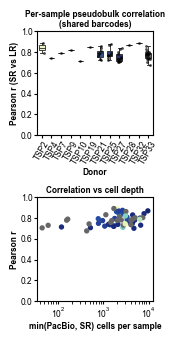

Matched samples (shared BC) with >= 20 cells both platforms: 56


In [11]:
per_sample_corr_shared = persample_corr(
    pb_sample_counts_sh, sr_sample_counts_sh, pb_sample_ncell_sh, sr_sample_ncell_sh,
    pb_samples, MIN_CELLS_PER_GROUP,
    "Per-sample pseudobulk correlation\n(shared barcodes)",
    figpath("02_03_shared_persample_correlation.pdf"))
print(f"Matched samples (shared BC) with >= {MIN_CELLS_PER_GROUP} cells both platforms: {len(per_sample_corr_shared)}")

## 6. Save correlation tables

Write the shared-barcode per-donor and per-sample correlation results to `csvs/`.

In [12]:
out_dir = f"{CSVS_DIR}/sr_vs_pacbio_gene_correlation"
os.makedirs(out_dir, exist_ok=True)

# shared-barcode
per_donor_corr_shared.to_csv(f"{out_dir}/per_donor_gene_correlation_sharedBC.csv")
if len(per_sample_corr_shared):
    per_sample_corr_shared.to_csv(f"{out_dir}/per_sample_gene_correlation_sharedBC.csv", index=False)

print("Wrote:")
for fn in ["per_donor_gene_correlation_sharedBC.csv", "per_sample_gene_correlation_sharedBC.csv"]:
    p = os.path.join(out_dir, fn)
    if os.path.exists(p):
        print("  ", p)

Wrote:
   ./../csvs/sr_vs_pacbio_gene_correlation/per_donor_gene_correlation_sharedBC.csv
   ./../csvs/sr_vs_pacbio_gene_correlation/per_sample_gene_correlation_sharedBC.csv


## 7. PacBio replicate check: T29 vs T30

Gene-level pseudobulk correlation between two **PacBio** samples, `T29` and `T30` — both TSP28 left-ovary tube_ids (`oval-L` / `oval-L1`), i.e. a PacBio-to-PacBio replicate reproducibility check. Same recipe as the SR-vs-PacBio panels (log1p CP10K pseudobulk, Pearson/Spearman over union-detected genes, 99th-percentile-capped axes). Saved to `figures/02_03_pacbio_T29_vs_T30_scatter.pdf`.

PacBio T29 (9,698 cells) vs T30 (7,722 cells) [TSP28 ovary]: Pearson 0.945 | Spearman 0.894 | 28,977 union-detected genes


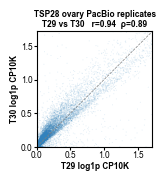

In [13]:
# --- PacBio-vs-PacBio replicate correlation: T29 vs T30 (both TSP28 left ovary) ---
# Same gene-level pseudobulk recipe as the SR-vs-PacBio comparison (log1p CP10K, correlation
# over union-detected genes), but between two PacBio tube_ids of the same tissue.
PB_PAIR = ["T29", "T30"]
pb_tube_labels = read_obs_col(PACBIO_GENES, "tube_id")
pair_sums, pair_ncell = pseudobulk_stream(PACBIO_GENES, "X", pb_tube_labels, PB_PAIR)
pair_pooled = cp10k_log1p(pool_by_symbol(pair_sums, pb_symbols, PB_PAIR))

a, b = pair_pooled[PB_PAIR[0]], pair_pooled[PB_PAIR[1]]
pr, sp, ng = corr_pair(a, b)
print(f"PacBio {PB_PAIR[0]} ({int(pair_ncell[0]):,} cells) vs {PB_PAIR[1]} "
      f"({int(pair_ncell[1]):,} cells) [TSP28 ovary]: "
      f"Pearson {pr:.3f} | Spearman {sp:.3f} | {ng:,} union-detected genes")

m = (a.values > 0) | (b.values > 0)
fig, ax = plt.subplots(figsize=(1.5, 1.5))
ax.scatter(a.values[m], b.values[m], s=0.5, alpha=0.15, edgecolors="none",
           color="#3182bd", rasterized=True)
lim = float(np.percentile(np.concatenate([a.values[m], b.values[m]]), 99))
ax.plot([0, lim], [0, lim], color="grey", lw=0.5, ls="--")
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_title(f"TSP28 ovary PacBio replicates\n{PB_PAIR[0]} vs {PB_PAIR[1]}   "
             f"r={pr:.2f}  ρ={sp:.2f}", pad=PANEL_TITLE_PAD)
ax.set_xlabel(f"{PB_PAIR[0]} log1p CP10K")
ax.set_ylabel(f"{PB_PAIR[1]} log1p CP10K")
plt.savefig(figpath(f"02_03_pacbio_T29_vs_T30_scatter.pdf"), dpi=600, bbox_inches="tight")
plt.show()